# 基于 PyTorch 的化学溶解度预测



In [1]:

from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
FEATURE_COLUMNS = [
    "MolWt",
    "LogP",
    "NumHDonors",
    "NumHAcceptors",
    "TPSA",
    "NumRotatableBonds",
    "AromaticProportion",
]
TARGET_COLUMN = "logS"
DATA_PATH = Path("chemical_solubility_data.csv")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
plt.rcParams["axes.unicode_minus"] = False


## 1. 任务与目标

这次项目的任务，是根据 7 个分子特征预测化学溶解度 `logS`。因为目标值是连续数值，所以它属于回归问题。

- 我们一开始参考了 AI 给出的初版方案，先把整体框架搭起来。
- 发现AI出现了一定的问题
- 然后进行了调整，与AI讨论确定技术路线

## 2. 数据分析与处理

这一部分是在了解数据基本情况、可视化观察和预处理放在一起

### 字段说明

| 字段 | 含义 |
| --- | --- |
| `MolWt` | 分子量 |
| `LogP` | 脂水分配相关特征 |
| `NumHDonors` | 氢键供体数量 |
| `NumHAcceptors` | 氢键受体数量 |
| `TPSA` | 拓扑极性表面积 |
| `NumRotatableBonds` | 可旋转键数量 |
| `AromaticProportion` | 芳香性比例 |
| `logS` | 化学溶解度目标值 |

In [2]:

df = pd.read_csv(DATA_PATH)
print(f"数据形状: {df.shape}")
print(f"缺失值总数: {int(df.isnull().sum().sum())}")
print(f"重复行数量: {int(df.duplicated().sum())}")
display(df.head())
display(df.describe().round(3))


数据形状: (500, 8)
缺失值总数: 0
重复行数量: 0


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,AromaticProportion,logS
0,249.816048,2.887132,6,8,34.792064,14,0.080180,-5.498953
1,480.285723,1.752675,3,6,58.635899,1,0.354771,-10.137778
2,392.797577,0.166693,5,0,89.171450,8,0.941726,-9.278005
3,339.463394,3.696565,7,11,74.515029,7,0.668573,-5.826272
4,162.407456,2.793118,7,3,148.167828,13,0.678670,-8.219001


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,AromaticProportion,logS
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,299.425,1.374,3.488,5.520,74.497,7.022,0.498,-6.727
std,119.475,1.998,2.283,3.502,43.446,4.337,0.292,3.638
min,102.025,-1.968,0.000,0.000,0.483,0.000,0.000,-16.784
25%,196.512,-0.396,2.000,3.000,36.047,3.000,0.270,-9.056
50%,305.265,1.303,4.000,5.000,75.631,7.000,0.487,-6.602
75%,402.450,3.084,5.250,9.000,112.335,11.000,0.756,-3.968
max,497.186,4.998,7.000,11.000,149.752,14.000,0.998,1.851


### 数据观察与处理说明

我们先画了特征分布图和相关性热力图，用来了解变量范围和特征之间的大致关系。在真正进入建模之前，我又重新整理了实现分工。

在实现过程中，我们和 AI 讨论后把训练集/测试集划分、标准化和回归指标放到 `sklearn`，把模型结构、`DataLoader`、训练循环和预测保留在 `PyTorch`。这样做的原因是，前面的预处理步骤本来就比较成熟，调包是一个合理选择，直接使用现成工具更好；后面的建模和训练继续放在 `PyTorch`，比较符合目前项目的实际情况

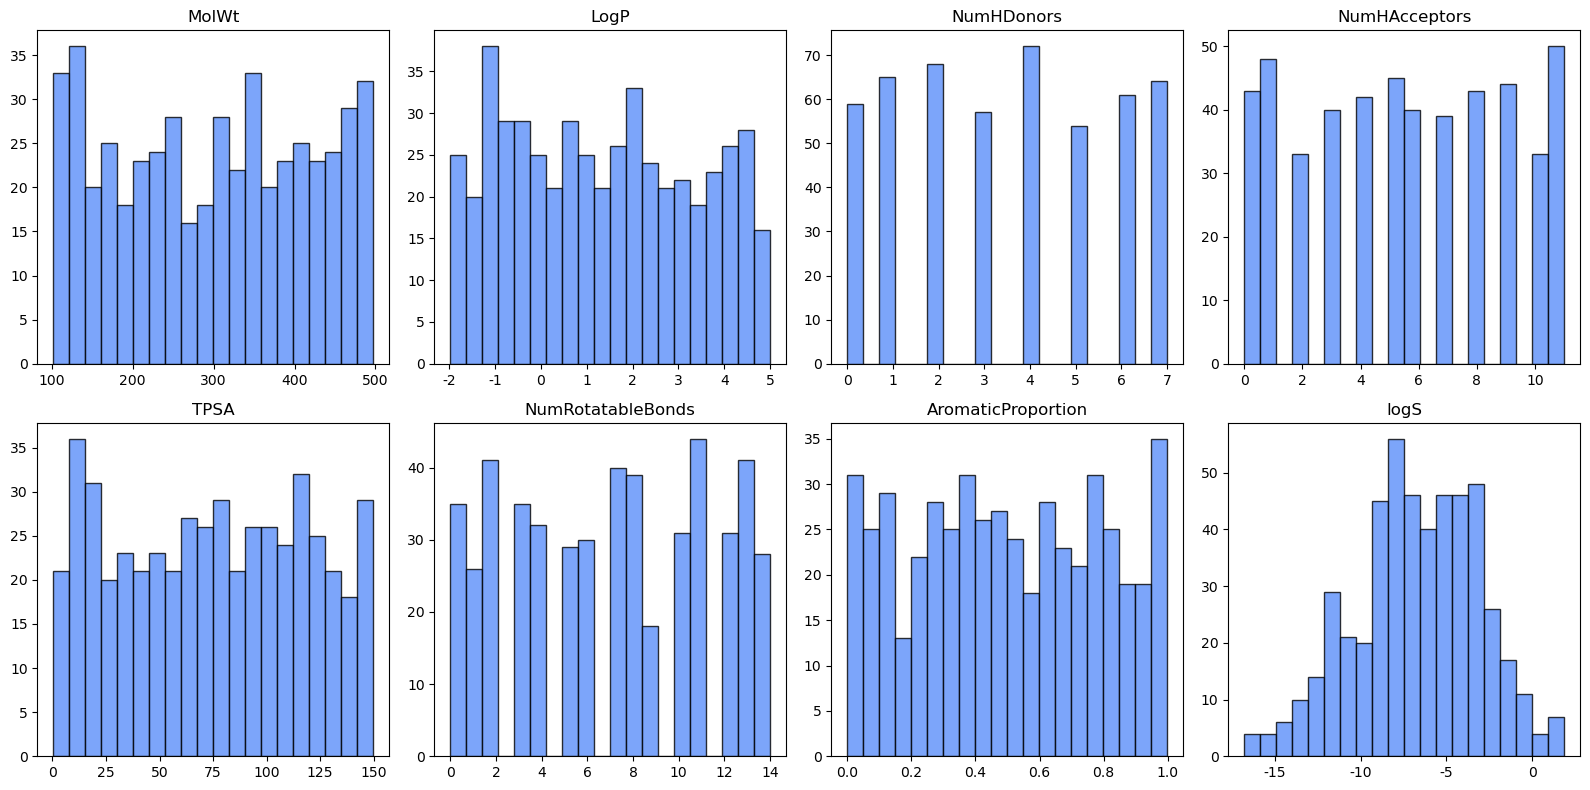

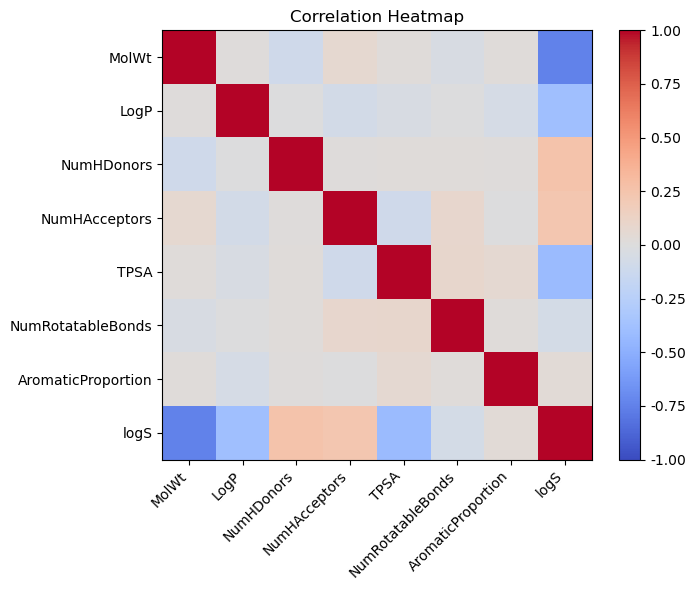

X_train shape: (400, 7)
X_test shape: (100, 7)
y_train shape: (400, 1)
y_test shape: (100, 1)


In [3]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, column in zip(axes.ravel(), FEATURE_COLUMNS + [TARGET_COLUMN]):
    ax.hist(df[column], bins=20, color="#5B8FF9", edgecolor="black", alpha=0.8)
    ax.set_title(column)
plt.tight_layout()
plt.show()

corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Heatmap")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

X = df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
y = df[[TARGET_COLUMN]].to_numpy(dtype=np.float32)

X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_scaled = scaler.transform(X_test_raw).astype(np.float32)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

print("X_train shape:", tuple(X_train.shape))
print("X_test shape:", tuple(X_test.shape))
print("y_train shape:", tuple(y_train.shape))
print("y_test shape:", tuple(y_test.shape))


## 3. 模型与训练

这一部分把模型定义、训练函数、配置检查和训练过程放在一起写。这样更容易看清楚，我到底是怎么发现 baseline 异常，又是怎么一步步排查到训练配置上的。

- 保留一个线性 baseline，作为最基础的对照模型。
- 保留一个结构比较简单的 MLP，作为最终比较对象。
- 初始 baseline 的那组结果不直接当结论，而是作为一次配置检查。

In [4]:

class LinearBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(len(FEATURE_COLUMNS), 1)

    def forward(self, x):
        return self.linear(x)

class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(len(FEATURE_COLUMNS), 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)

def evaluate_model(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy().reshape(-1)
        targets = y_tensor.cpu().numpy().reshape(-1)

    mse = mean_squared_error(targets, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(targets, predictions)
    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "r2": float(r2),
        "predictions": predictions,
        "targets": targets,
    }

def train_model(model, train_dataset, test_dataset, lr, epochs, batch_size, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
    )
    full_train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
    full_test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": []}

    for _ in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            prediction = model(batch_x)
            loss = criterion(prediction, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_x, train_y = next(iter(full_train_loader))
            test_x, test_y = next(iter(full_test_loader))
            history["train_loss"].append(float(criterion(model(train_x), train_y).item()))
            history["test_loss"].append(float(criterion(model(test_x), test_y).item()))

    return model, history


### 配置检查与排查过程

AI 初版里，线性 baseline 的结果异常差，结果非常离谱，不太正常。然后开始排除错误：进行了一下尝试。

- 训练集和测试集划分是否合理；
- 标准化是不是只在训练集上 `fit`；
- `y` 的维度有没有统一成 `(N, 1)`；
- `RMSE` 和 `R^2` 的公式是不是写错了。

把这些地方都核对过以后，我们把主要问题定位到 baseline 的训练配置不合适，AI采用了和神经网络相同的参数，这个不适用于线性模型。

In [5]:

set_seed()
linear_initial_model = LinearBaseline()
linear_initial_model, linear_initial_history = train_model(
    linear_initial_model,
    train_dataset,
    test_dataset,
    lr=1e-3,
    epochs=200,
    batch_size=64,
)
linear_initial_train_metrics = evaluate_model(linear_initial_model, X_train, y_train)
linear_initial_test_metrics = evaluate_model(linear_initial_model, X_test, y_test)

display(
    pd.DataFrame(
        {
            "Train RMSE": [linear_initial_train_metrics["rmse"]],
            "Train R2": [linear_initial_train_metrics["r2"]],
            "Test RMSE": [linear_initial_test_metrics["rmse"]],
            "Test R2": [linear_initial_test_metrics["r2"]],
        },
        index=["LinearBaseline 初始训练配置"],
    ).round(4)
)


,Train RMSE,Train R2,Test RMSE,Test R2
LinearBaseline 初始训练配置,6.0365,-1.7157,5.8021,-1.7261


In [6]:

set_seed()
linear_model = LinearBaseline()
linear_model, linear_history = train_model(
    linear_model,
    train_dataset,
    test_dataset,
    lr=0.02,
    epochs=300,
    batch_size=64,
)
linear_train_metrics = evaluate_model(linear_model, X_train, y_train)
linear_test_metrics = evaluate_model(linear_model, X_test, y_test)

display(
    pd.DataFrame(
        {
            "Train RMSE": [linear_train_metrics["rmse"]],
            "Train R2": [linear_train_metrics["r2"]],
            "Test RMSE": [linear_test_metrics["rmse"]],
            "Test R2": [linear_test_metrics["r2"]],
        },
        index=["LinearBaseline 调整后训练配置"],
    ).round(4)
)


,Train RMSE,Train R2,Test RMSE,Test R2
LinearBaseline 调整后训练配置,0.6239,0.971,0.7351,0.9562


In [7]:

set_seed()
mlp_model = MLPModel()
mlp_model, mlp_history = train_model(
    mlp_model,
    train_dataset,
    test_dataset,
    lr=1e-3,
    epochs=200,
    batch_size=64,
)
mlp_train_metrics = evaluate_model(mlp_model, X_train, y_train)
mlp_test_metrics = evaluate_model(mlp_model, X_test, y_test)

display(
    pd.DataFrame(
        {
            "Train RMSE": [mlp_train_metrics["rmse"]],
            "Train R2": [mlp_train_metrics["r2"]],
            "Test RMSE": [mlp_test_metrics["rmse"]],
            "Test R2": [mlp_test_metrics["r2"]],
        },
        index=["MLPModel 最终训练配置"],
    ).round(4)
)


,Train RMSE,Train R2,Test RMSE,Test R2
MLPModel 最终训练配置,0.4645,0.9839,0.6913,0.9613


初始 baseline、调整后 baseline 和 MLP 的训练历史放在一起看，可以比较直观地看出：最初异常结果更多是配置问题，而不是前面数据处理出了明显错误。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\234448984.py:15: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\234448984.py:15: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\234448984.py:15: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\234448984.py:15: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\234448984.py:15: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31576\23

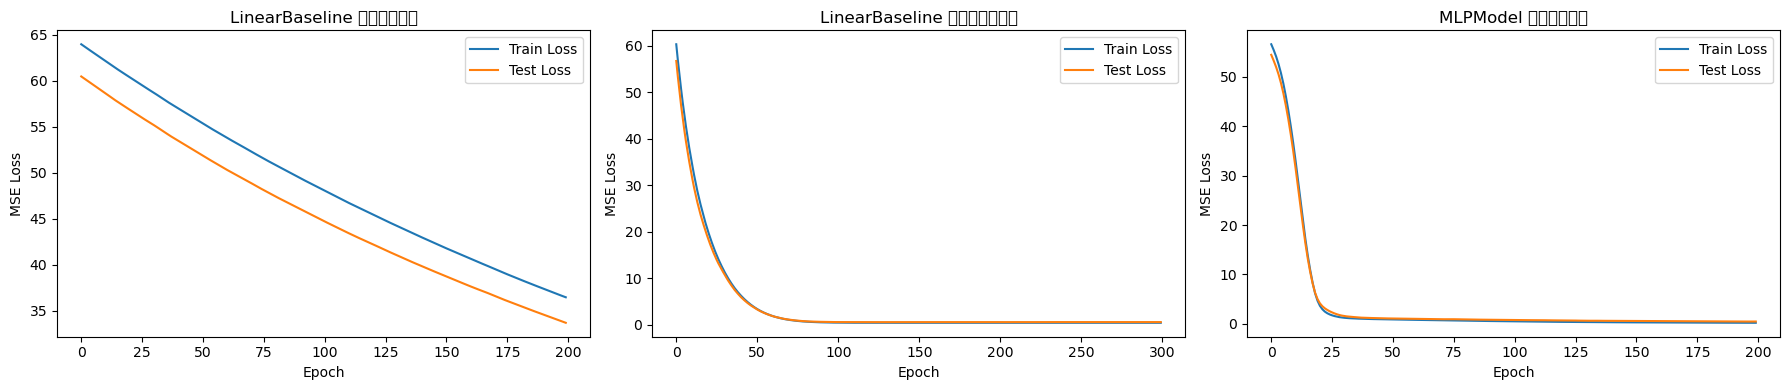

In [8]:

histories = [
    ("LinearBaseline 初始训练配置", linear_initial_history),
    ("LinearBaseline 调整后训练配置", linear_history),
    ("MLPModel 最终训练配置", mlp_history),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (title, history) in zip(axes, histories):
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["test_loss"], label="Test Loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
plt.tight_layout()
plt.show()


## 4. 结论

正式结论只基于修正后的线性 baseline 和 MLP 来比较，不直接根据最初异常结果下判断。下面先给出结果表，再结合预测散点图和残差图看最终表现。

表1 线性基线配置检查


,Train RMSE,Train R2,Test RMSE,Test R2
LinearBaseline 初始训练配置,6.0365,-1.7157,5.8021,-1.7261
LinearBaseline 调整后训练配置,0.6239,0.9710,0.7351,0.9562


表2 最终模型结果对比


,Train RMSE,Train R2,Test RMSE,Test R2
LinearBaseline,0.6239,0.9710,0.7351,0.9562
MLPModel,0.4645,0.9839,0.6913,0.9613


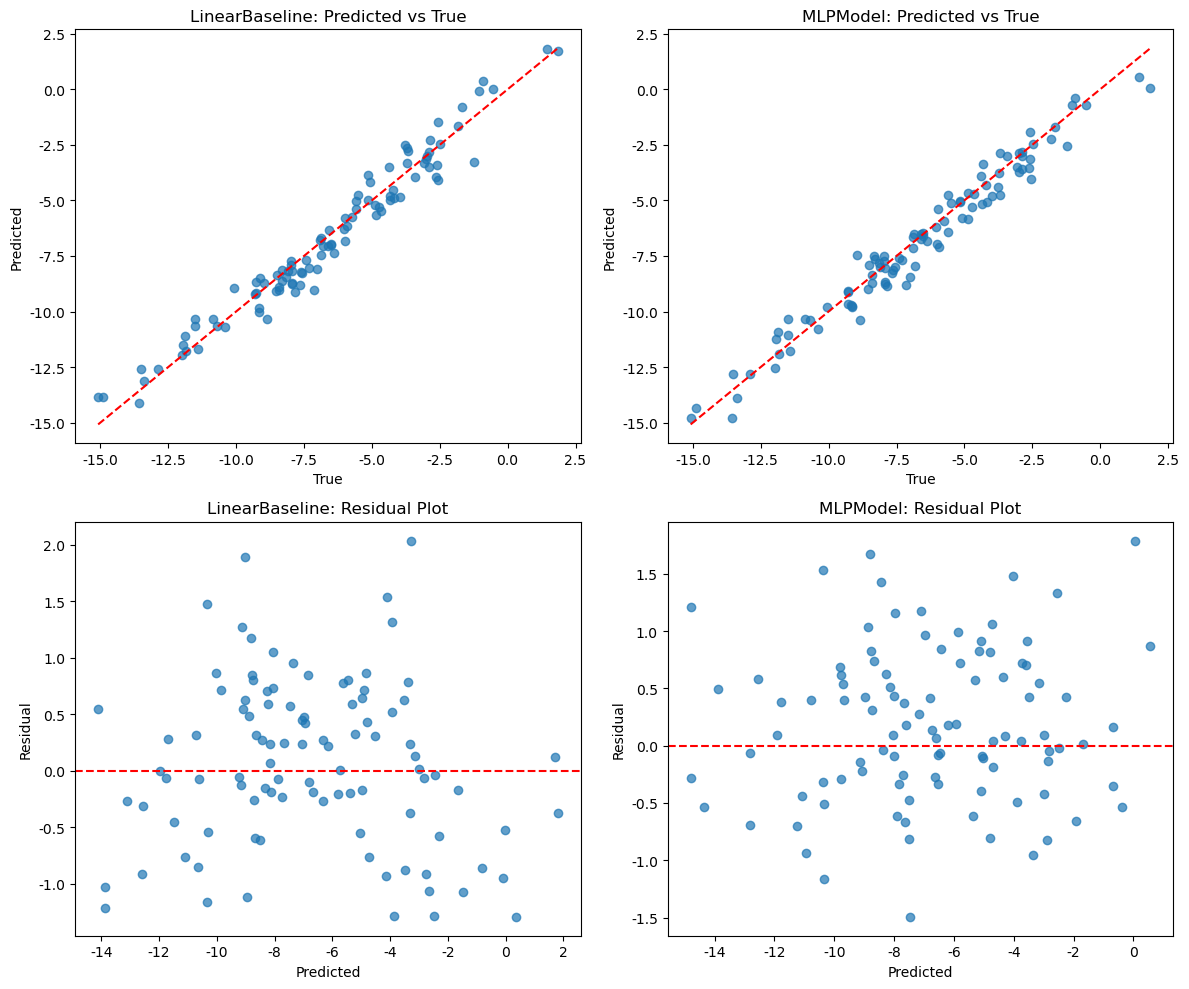

In [9]:

print("表1 线性基线配置检查")
display(
    pd.DataFrame(
        {
            "Train RMSE": [
                linear_initial_train_metrics["rmse"],
                linear_train_metrics["rmse"],
            ],
            "Train R2": [
                linear_initial_train_metrics["r2"],
                linear_train_metrics["r2"],
            ],
            "Test RMSE": [
                linear_initial_test_metrics["rmse"],
                linear_test_metrics["rmse"],
            ],
            "Test R2": [
                linear_initial_test_metrics["r2"],
                linear_test_metrics["r2"],
            ],
        },
        index=["LinearBaseline 初始训练配置", "LinearBaseline 调整后训练配置"],
    ).round(4)
)

print("表2 最终模型结果对比")
display(
    pd.DataFrame(
        {
            "Train RMSE": [
                linear_train_metrics["rmse"],
                mlp_train_metrics["rmse"],
            ],
            "Train R2": [
                linear_train_metrics["r2"],
                mlp_train_metrics["r2"],
            ],
            "Test RMSE": [
                linear_test_metrics["rmse"],
                mlp_test_metrics["rmse"],
            ],
            "Test R2": [
                linear_test_metrics["r2"],
                mlp_test_metrics["r2"],
            ],
        },
        index=["LinearBaseline", "MLPModel"],
    ).round(4)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(linear_test_metrics["targets"], linear_test_metrics["predictions"], alpha=0.7)
axes[0, 0].plot(
    [linear_test_metrics["targets"].min(), linear_test_metrics["targets"].max()],
    [linear_test_metrics["targets"].min(), linear_test_metrics["targets"].max()],
    color="red",
    linestyle="--",
)
axes[0, 0].set_title("LinearBaseline: Predicted vs True")
axes[0, 0].set_xlabel("True")
axes[0, 0].set_ylabel("Predicted")

axes[0, 1].scatter(mlp_test_metrics["targets"], mlp_test_metrics["predictions"], alpha=0.7)
axes[0, 1].plot(
    [mlp_test_metrics["targets"].min(), mlp_test_metrics["targets"].max()],
    [mlp_test_metrics["targets"].min(), mlp_test_metrics["targets"].max()],
    color="red",
    linestyle="--",
)
axes[0, 1].set_title("MLPModel: Predicted vs True")
axes[0, 1].set_xlabel("True")
axes[0, 1].set_ylabel("Predicted")

linear_residuals = linear_test_metrics["targets"] - linear_test_metrics["predictions"]
mlp_residuals = mlp_test_metrics["targets"] - mlp_test_metrics["predictions"]

axes[1, 0].scatter(linear_test_metrics["predictions"], linear_residuals, alpha=0.7)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("LinearBaseline: Residual Plot")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Residual")

axes[1, 1].scatter(mlp_test_metrics["predictions"], mlp_residuals, alpha=0.7)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("MLPModel: Residual Plot")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


从最终结果看，初始训练配置下的线性 baseline 测试集 `RMSE` 约为 5.802，明显不在合理范围内；调整后线性 baseline 的测试集 `RMSE` 约为 0.735，MLP 的测试集 `RMSE` 约为 0.691，两者差值约为 0.044。更合适的结论是：修正后的 baseline 和 MLP 结果接近，MLP 略优，但差距没有最初异常结果显示得那么大。

In [8]:

rmse_gap = abs(mlp_test_metrics["rmse"] - linear_test_metrics["rmse"])
print(f"初始线性 baseline Test RMSE: {linear_initial_test_metrics['rmse']:.4f}")
print(f"调整后线性 baseline Test RMSE: {linear_test_metrics['rmse']:.4f}")
print(f"MLP Test RMSE: {mlp_test_metrics['rmse']:.4f}")
print(f"最终两者 Test RMSE 差值: {rmse_gap:.4f}")
print("更合理的结论：初始训练配置下线性 baseline 未充分收敛；调整后线性 baseline 恢复到合理范围；MLP 略优，但差距没有初始异常结果显示得那么大。")


初始线性 baseline Test RMSE: 5.8021
调整后线性 baseline Test RMSE: 0.7351
MLP Test RMSE: 0.6913
最终两者 Test RMSE 差值: 0.0438
更合理的结论：初始训练配置下线性 baseline 未充分收敛；调整后线性 baseline 恢复到合理范围；MLP 略优，但差距没有初始异常结果显示得那么大。


In [ ]:
import copy
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

# 防止按顺序运行时依赖缺失：如果辅助函数尚未定义，则在本单元补齐
if "evaluate_metrics" not in globals():
    def evaluate_metrics(model, X_tensor, y_tensor):
        model.eval()
        with torch.no_grad():
            pred = model(X_tensor).cpu().numpy().reshape(-1)
            true = y_tensor.cpu().numpy().reshape(-1)
        mse = mean_squared_error(true, pred)
        rmse = mse ** 0.5
        mae = mean_absolute_error(true, pred)
        r2 = r2_score(true, pred)
        return {"rmse": float(rmse), "mae": float(mae), "r2": float(r2), "pred": pred, "true": true}

if "train_with_val_selection" not in globals():
    def train_with_val_selection(model, train_x, train_y, val_x, val_y, lr=1e-3, epochs=300, batch_size=64, patience=40):
        train_ds = TensorDataset(train_x, train_y)
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            generator=torch.Generator().manual_seed(SEED),
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        best_state = copy.deepcopy(model.state_dict())
        best_val_loss = float("inf")
        best_epoch = 0
        wait = 0

        for epoch in range(1, epochs + 1):
            model.train()
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_loss = float(criterion(model(val_x), val_y).item())

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

        model.load_state_dict(best_state)
        return model, best_epoch, best_val_loss


def run_kfold_cv(model_factory, X_np, y_np, lr, epochs, batch_size, patience, n_splits=5, seed=SEED):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_records = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_np), start=1):
        X_train_raw = X_np[train_idx]
        y_train = y_np[train_idx]
        X_test_raw = X_np[test_idx]
        y_test = y_np[test_idx]

        X_train_raw, X_val_raw, y_train, y_val = train_test_split(
            X_train_raw,
            y_train,
            test_size=0.15,
            random_state=seed,
            shuffle=True,
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)
        X_val_scaled = scaler.transform(X_val_raw).astype(np.float32)
        X_test_scaled = scaler.transform(X_test_raw).astype(np.float32)

        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
        X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.float32)
        X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32)

        set_seed(seed + fold_idx)
        model = model_factory()
        model, best_epoch, _ = train_with_val_selection(
            model,
            X_train_t,
            y_train_t,
            X_val_t,
            y_val_t,
            lr=lr,
            epochs=epochs,
            batch_size=batch_size,
            patience=patience,
        )

        test_metrics = evaluate_metrics(model, X_test_t, y_test_t)
        fold_records.append(
            {
                "Fold": fold_idx,
                "Best Epoch": best_epoch,
                "Test RMSE": test_metrics["rmse"],
                "Test MAE": test_metrics["mae"],
                "Test R2": test_metrics["r2"],
            }
        )

    return pd.DataFrame(fold_records)


linear_cv_df = run_kfold_cv(
    model_factory=LinearBaseline,
    X_np=X,
    y_np=y,
    lr=0.02,
    epochs=400,
    batch_size=64,
    patience=60,
    n_splits=5,
)

mlp_cv_df = run_kfold_cv(
    model_factory=MLPModel,
    X_np=X,
    y_np=y,
    lr=1e-3,
    epochs=400,
    batch_size=64,
    patience=60,
    n_splits=5,
)

summary_df = pd.DataFrame(
    {
        "Model": ["LinearBaseline", "MLPModel"],
        "CV RMSE Mean": [linear_cv_df["Test RMSE"].mean(), mlp_cv_df["Test RMSE"].mean()],
        "CV RMSE Std": [linear_cv_df["Test RMSE"].std(ddof=1), mlp_cv_df["Test RMSE"].std(ddof=1)],
        "CV MAE Mean": [linear_cv_df["Test MAE"].mean(), mlp_cv_df["Test MAE"].mean()],
        "CV R2 Mean": [linear_cv_df["Test R2"].mean(), mlp_cv_df["Test R2"].mean()],
        "CV R2 Std": [linear_cv_df["Test R2"].std(ddof=1), mlp_cv_df["Test R2"].std(ddof=1)],
    }
).set_index("Model")

print("LinearBaseline 5-fold每折结果")
display(linear_cv_df.round(4))
print("MLPModel 5-fold每折结果")
display(mlp_cv_df.round(4))
print("5-fold交叉验证汇总（均值±波动）")
display(summary_df.round(4))

In [10]:
import copy
from sklearn.metrics import mean_absolute_error

# 更稳健的数据集划分：70%训练 / 15%验证 / 15%测试
X_trainval_raw, X_test_raw, y_trainval_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
)

val_ratio = 0.15 / 0.85
X_train_raw, X_val_raw, y_train_np, y_val_np = train_test_split(
    X_trainval_raw,
    y_trainval_np,
    test_size=val_ratio,
    random_state=SEED,
    shuffle=True,
)

scaler_701515 = StandardScaler()
X_train_scaled = scaler_701515.fit_transform(X_train_raw).astype(np.float32)
X_val_scaled = scaler_701515.transform(X_val_raw).astype(np.float32)
X_test_scaled = scaler_701515.transform(X_test_raw).astype(np.float32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32)

print("70/15/15 划分结果:")
print("Train:", tuple(X_train_t.shape), "Val:", tuple(X_val_t.shape), "Test:", tuple(X_test_t.shape))


def evaluate_metrics(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        pred = model(X_tensor).cpu().numpy().reshape(-1)
        true = y_tensor.cpu().numpy().reshape(-1)
    mse = mean_squared_error(true, pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return {"rmse": float(rmse), "mae": float(mae), "r2": float(r2), "pred": pred, "true": true}


def train_with_val_selection(model, train_x, train_y, val_x, val_y, lr=1e-3, epochs=300, batch_size=64, patience=40):
    train_ds = TensorDataset(train_x, train_y)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = float(criterion(model(val_x), val_y).item())

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss


set_seed()
linear_val_model = LinearBaseline()
linear_val_model, linear_best_epoch, linear_best_val = train_with_val_selection(
    linear_val_model,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    lr=0.02,
    epochs=400,
    batch_size=64,
    patience=60,
)

set_seed()
mlp_val_model = MLPModel()
mlp_val_model, mlp_best_epoch, mlp_best_val = train_with_val_selection(
    mlp_val_model,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    lr=1e-3,
    epochs=400,
    batch_size=64,
    patience=60,
)

linear_val_metrics = evaluate_metrics(linear_val_model, X_val_t, y_val_t)
linear_test_metrics_701515 = evaluate_metrics(linear_val_model, X_test_t, y_test_t)
mlp_val_metrics = evaluate_metrics(mlp_val_model, X_val_t, y_val_t)
mlp_test_metrics_701515 = evaluate_metrics(mlp_val_model, X_test_t, y_test_t)

display(
    pd.DataFrame(
        {
            "Best Epoch": [linear_best_epoch, mlp_best_epoch],
            "Val RMSE": [linear_val_metrics["rmse"], mlp_val_metrics["rmse"]],
            "Val MAE": [linear_val_metrics["mae"], mlp_val_metrics["mae"]],
            "Val R2": [linear_val_metrics["r2"], mlp_val_metrics["r2"]],
            "Test RMSE": [linear_test_metrics_701515["rmse"], mlp_test_metrics_701515["rmse"]],
            "Test MAE": [linear_test_metrics_701515["mae"], mlp_test_metrics_701515["mae"]],
            "Test R2": [linear_test_metrics_701515["r2"], mlp_test_metrics_701515["r2"]],
        },
        index=["LinearBaseline(70/15/15)", "MLPModel(70/15/15)"],
    ).round(4)
)

print("70/15/15 测试集对比:")
print(f"Linear Test RMSE: {linear_test_metrics_701515['rmse']:.4f}, R2: {linear_test_metrics_701515['r2']:.4f}")
print(f"MLP Test RMSE: {mlp_test_metrics_701515['rmse']:.4f}, R2: {mlp_test_metrics_701515['r2']:.4f}")

70/15/15 划分结果:
Train: (350, 7) Val: (75, 7) Test: (75, 7)


,Best Epoch,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
LinearBaseline(70/15/15),319,0.5810,0.4818,0.9765,0.7420,0.6058,0.9568
MLPModel(70/15/15),334,0.5561,0.4312,0.9785,0.6688,0.5255,0.9649


70/15/15 测试集对比:
Linear Test RMSE: 0.7420, R2: 0.9568
MLP Test RMSE: 0.6688, R2: 0.9649


## 6. Bug 修复后进一步提升预测准确性

在修复运行顺序依赖问题后，这里用更强的 PyTorch 模型做一次增强评估：
- 使用二阶特征扩展（PolynomialFeatures）捕捉非线性与交互项
- 使用更深的 MLP + AdamW + HuberLoss + 学习率调度
- 使用 5-fold 交叉验证对比改进前后的稳定性

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


class TunedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_tuned_with_val(model, train_x, train_y, val_x, val_y, lr=2e-3, epochs=500, batch_size=64, patience=70):
    train_ds = TensorDataset(train_x, train_y)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=20,
    )
    criterion = nn.SmoothL1Loss(beta=0.5)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = float(criterion(model(val_x), val_y).item())
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_epoch


def run_tuned_kfold_cv(X_np, y_np, n_splits=5, seed=SEED):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    records = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_np), start=1):
        X_train_raw = X_np[train_idx]
        y_train = y_np[train_idx]
        X_test_raw = X_np[test_idx]
        y_test = y_np[test_idx]

        X_train_raw, X_val_raw, y_train, y_val = train_test_split(
            X_train_raw,
            y_train,
            test_size=0.15,
            random_state=seed,
            shuffle=True,
        )

        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_raw)
        X_val_poly = poly.transform(X_val_raw)
        X_test_poly = poly.transform(X_test_raw)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_poly).astype(np.float32)
        X_val_scaled = scaler.transform(X_val_poly).astype(np.float32)
        X_test_scaled = scaler.transform(X_test_poly).astype(np.float32)

        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
        X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.float32)
        X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32)

        set_seed(seed + fold_idx)
        tuned_model = TunedMLP(input_dim=X_train_t.shape[1])
        tuned_model, best_epoch = train_tuned_with_val(
            tuned_model,
            X_train_t,
            y_train_t,
            X_val_t,
            y_val_t,
        )

        fold_metrics = evaluate_metrics(tuned_model, X_test_t, y_test_t)
        records.append(
            {
                "Fold": fold_idx,
                "Best Epoch": best_epoch,
                "Test RMSE": fold_metrics["rmse"],
                "Test MAE": fold_metrics["mae"],
                "Test R2": fold_metrics["r2"],
            }
        )

    return pd.DataFrame(records)


tuned_cv_df = run_tuned_kfold_cv(X, y, n_splits=5)

base_mlp_rmse_mean = float(mlp_cv_df["Test RMSE"].mean())
tuned_rmse_mean = float(tuned_cv_df["Test RMSE"].mean())
rmse_improve = base_mlp_rmse_mean - tuned_rmse_mean

compare_df = pd.DataFrame(
    {
        "Model": ["MLPModel(原5-fold)", "TunedMLP+Poly2(5-fold)"],
        "CV RMSE Mean": [
            base_mlp_rmse_mean,
            tuned_rmse_mean,
        ],
        "CV RMSE Std": [
            float(mlp_cv_df["Test RMSE"].std(ddof=1)),
            float(tuned_cv_df["Test RMSE"].std(ddof=1)),
        ],
        "CV MAE Mean": [
            float(mlp_cv_df["Test MAE"].mean()),
            float(tuned_cv_df["Test MAE"].mean()),
        ],
        "CV R2 Mean": [
            float(mlp_cv_df["Test R2"].mean()),
            float(tuned_cv_df["Test R2"].mean()),
        ],
    }
).set_index("Model")

print("TunedMLP + 二阶特征 5-fold每折结果")
display(tuned_cv_df.round(4))
print("改进前后对比")
display(compare_df.round(4))
print(f"RMSE 改善值（原 - 新）: {rmse_improve:.4f}")

## 5. 总结与反思

这次项目给我的最大收获，是理解了模型比较必须建立在公平训练的前提上。如果只看最开始那组异常结果，很容易把差距写得过大，而在经过自己的优化后大大缩小了差距，但自己检查完数据处理、指标公式和训练配置之后，结论就会更稳妥。

另外，这次过程也让我更清楚 AI 在课程项目里的作用。AI 初版可以帮助起步，也能帮我讨论实现路线，但它给出的代码和结论不能直接当成最终答案，它出现了非常离谱的错误，所以必需人工核实。

另外，版本管理是必要且重要的，这次出现了AI意外修改，导致丢失代码的情况，使用必须做好版本控制